# Gapfill with U-Net model

This notebook shows how to gapfill with a fitted model.

In [1]:
# Install mindthegap from GitHub.
%pip install -qU "git+https://github.com/SAFS-Varanasi-Internship/mindthegap.git"

Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.pyplot as plt
import mindthegap as mtg
from mindthegap import viz

## Load a model bundle

Use a local bundle directory or a Hugging Face repository ID. `load_model_bundle` returns the model and the resolved `Options` (`options.json`) -- the single source of truth for the exact channel order and standardization needed for prediction. The companion `load_bundle_metrics` reads back the run's `metrics.json` (final metrics, run metadata, and training history) recorded from the `TrainingResult` when the bundle was saved.

In [ ]:
from pathlib import Path

bundle_source = "../models/io-shared-public-unet-bundle"

if Path(bundle_source).is_dir():
    bundle_path = Path(bundle_source)
else:
    from huggingface_hub import snapshot_download
    bundle_path = Path(snapshot_download(repo_id=bundle_source))

model, options = mtg.load_model_bundle(bundle_path)
input_vars = options.data.input_names
print(f"Target: {options.data.target_name}")
print(f"Inputs: {input_vars}")

# metrics.json records the training run (metrics, metadata, history). Use it to
# confirm which model/version produced this bundle and how well it validated.
run = mtg.load_bundle_metrics(bundle_path)
print(f"mindthegap version: {run['metadata'].get('mindthegap_version', 'unknown')}")
print(f"Validation metrics: {run['metrics']}")

## Prepare a gap-fill dataset

The loaded `options` already carries the exact training configuration, so run `prepare_model_data(..., mode="gapfill")` directly. Gap-fill mode reuses the recorded standardization and produces the inference channels (no synthetic clouds), so the inputs match the trained model exactly. For another bundle, replace `mtg.demo_data` with the matching dataset loader (see `data.data_source` in `options.json`).

In [3]:
ds, target, missing_flag, land_flag = mtg.demo_data(
    "io-shared-public",
    region=options.data.region_name,
    time_slice=slice(*options.data.time_bounds.split(" to ")),
)

# The bundle's options already carry the exact training configuration (variable
# names, transforms, standardization); just run prepare_model_data directly.
# Gap-fill mode: no synthetic clouds, reuses the recorded standardization.
ds_std = mtg.prepare_model_data(ds, options, mode="gapfill")

missing_inputs = [name for name in input_vars if name not in ds_std]
if missing_inputs:
    raise ValueError(
        f"Prepared dataset is missing bundle inputs: {missing_inputs}"
    )
ds_std

Channels created (9 total):
  1. observed_target
  2. observed_target_m1
  3. observed_target_p1
  4. day_sin
  5. day_cos
  6. estimate_flag
  7. unavailable_flag
  8. observed_flag
  9. land_flag
Target standardization: mean=0.0000, std=1.0000
Dataset is LAZY (not in memory): Frozen({'time': (60, 60, 60, 60, 60, 60, 5), 'lat': (64, 64, 40), 'lon': (64, 64, 64, 48)})


<xarray.Dataset> Size: 412MB
Dimensions:             (time: 365, lat: 168, lon: 240)
Coordinates:
  * time                (time) datetime64[ns] 3kB 2000-01-01 ... 2000-12-31
  * lat                 (lat) float32 672B 30.0 29.75 29.5 ... -11.5 -11.75
  * lon                 (lon) float32 960B 42.0 42.25 42.5 ... 101.2 101.5 101.8
Data variables:
    full_target         (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    observed_target     (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    observed_target_m1  (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    observed_target_p1  (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    day_sin             (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    day_cos             (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    estimate_flag       (time, lat, lon) int8 15MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    unavailable_flag    (time, lat, lon) int8 15MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    observed_flag       (time, lat, lon) int8 15MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    land_flag           (time, lat, lon) int8 15MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
Attributes: (12/92)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L3_MY_009_103
    ...                              ...
    time_coverage_end:               2024-04-18T02:58:23Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2024-04-16T21:12:05Z
    title:                           cmems_obs-oc_glo_bgc-plankton_my_l3-mult...
    westernmost_longitude:           -180.0
    westernmost_valid_longitude:     -180.0

## Observed vs. gap-filled (standardized space)

`mtg.gapfill_std` is a low-level function: it returns the raw model output as an `xarray.Dataset` with a `gapfilled_target` variable in the model's **standardized** space (no unstandardizing or de-logging). Here we plot the standardized observed field beside it. Recovering the original units is the job of the higher-level `gapfill(ds)` (a later function).

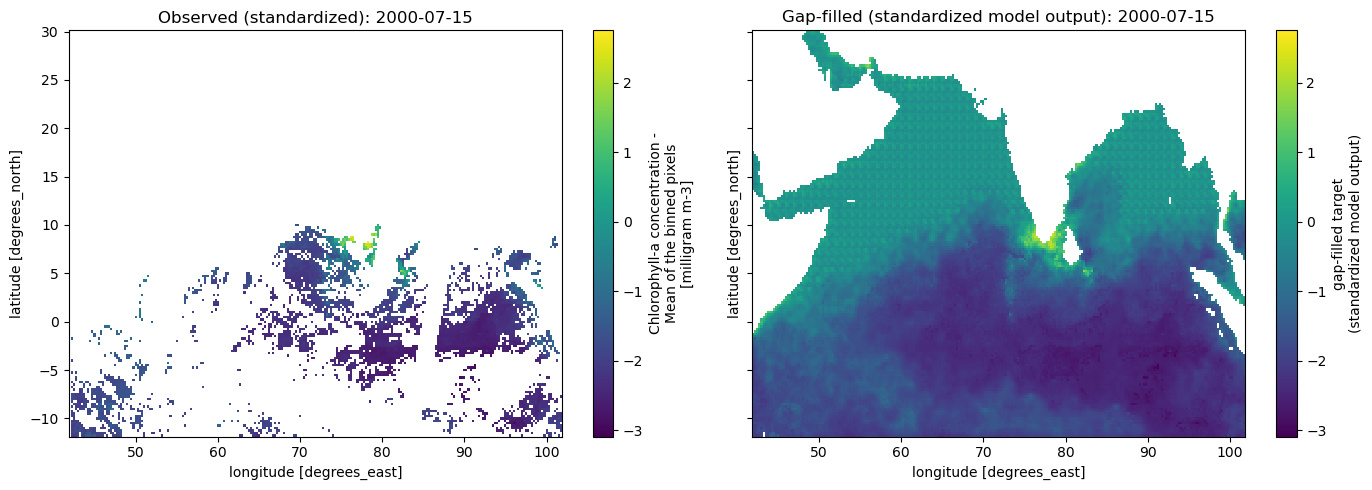

In [11]:
date = "2000-07-15"

gapfilled = mtg.gapfill_std(ds_std, model, options, time=date)
prediction = gapfilled["gapfilled_target"].isel(time=0)
observed = ds_std["observed_target"].sel(time=date)

# mask land
land = ds_std["land_flag"].sel(time=date)
observed = observed.where(land == 0)
prediction = prediction.where(land == 0)

vmin = float(min(observed.min(), prediction.min()))
vmax = float(max(observed.max(), prediction.max()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
observed.plot(ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title(f"Observed (standardized): {date}")
prediction.plot(ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title(f"Gap-filled (standardized model output): {date}")
plt.tight_layout()
plt.show()

## Individual panels

Each panel is available independently, so custom layouts do not duplicate plotting or prediction logic.

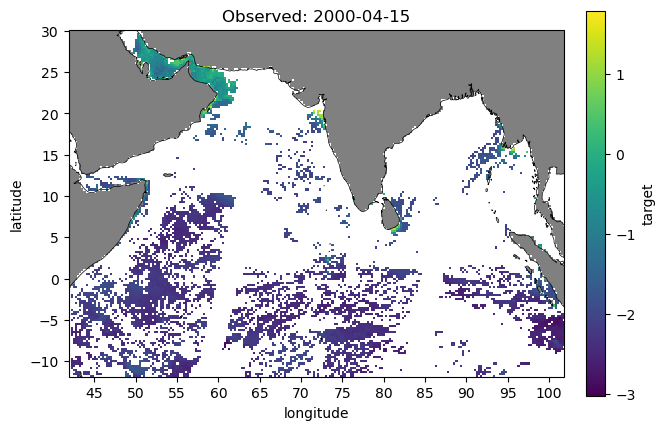

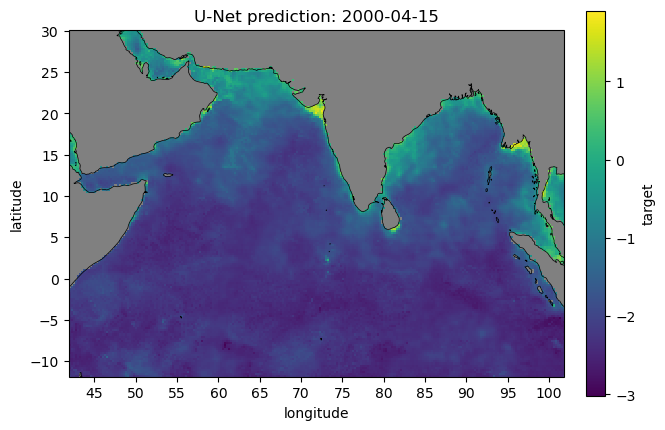

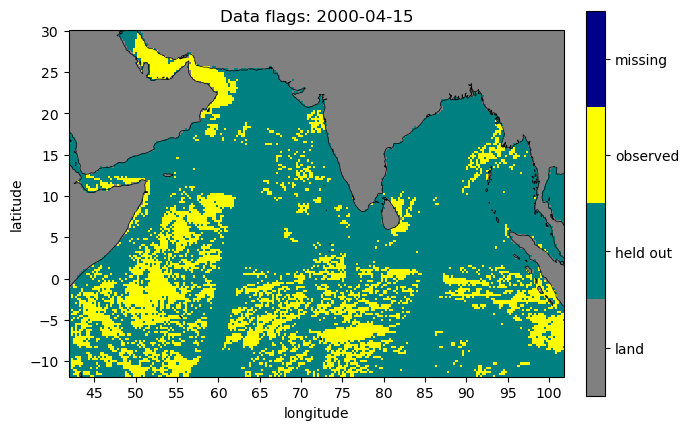

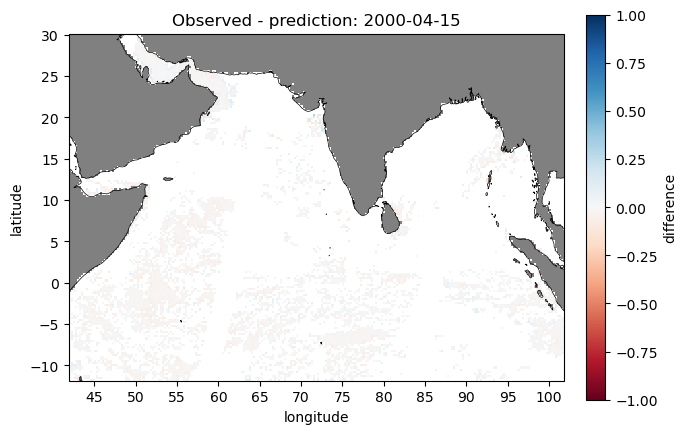

In [6]:
date = "2000-04-15"

viz.plot_observed(ds_std, options, date)
viz.plot_prediction(ds_std, model, options, date)
viz.plot_flags(ds_std, date)
viz.plot_difference(ds_std, model, options, date)

## Standard four-panel view

The composite calls the same individual panel functions and predicts only once.

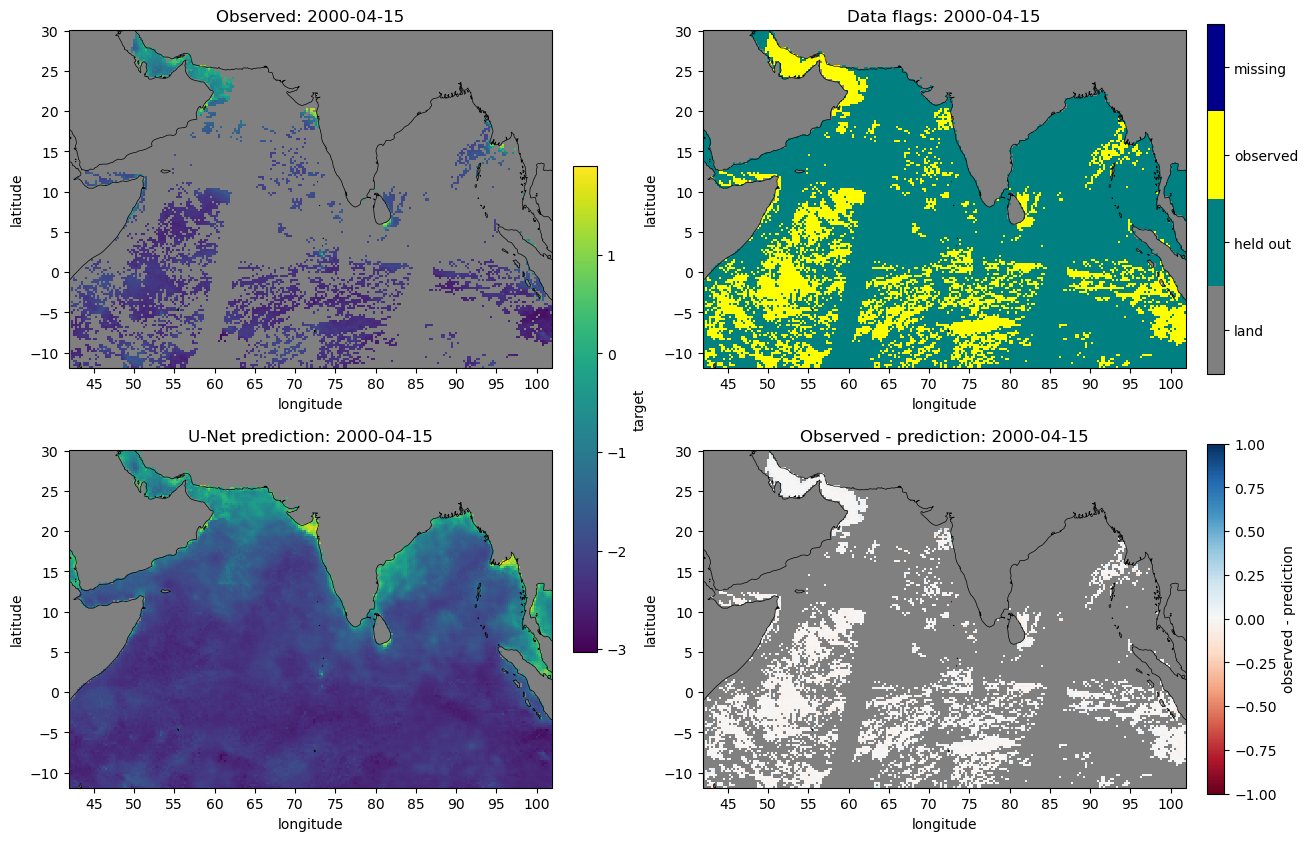

In [15]:
fig, axes = viz.plot_prediction_observed(
    ds_std,
    model,
    options,
    date,
    difference_limit=1.0,
)
plt.show()